In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [9]:
import pandas as pd

df = pd.read_csv("sales.csv")

df.head()

,Date,Customer_ID,Age,Gender,Product,Product_Category,Quantity,Unit_Price,Sales
0,2024-01-05,C001,25,Male,Laptop,Electronics,1,50000,50000
1,2024-01-08,C002,32,Female,Mobile,Electronics,2,20000,40000
2,2024-01-15,C003,41,Male,Shirt,Clothing,3,1200,3600
3,2024-02-03,C004,22,Female,Shoes,Footwear,1,2500,2500
4,2024-02-10,C005,35,Male,Laptop,Electronics,1,55000,55000


In [10]:
import os

print(os.getcwd())
print(os.listdir())

e:\OASIS INFOTECH\Data Analytics\Retails Sales data
['main.ipynb', 'sales.csv']


In [11]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 5
Number of columns: 9

Column names:
['Date', 'Customer_ID', 'Age', 'Gender', 'Product', 'Product_Category', 'Quantity', 'Unit_Price', 'Sales']

Data types:
Date                  str
Customer_ID           str
Age                 int64
Gender                str
Product               str
Product_Category      str
Quantity            int64
Unit_Price          int64
Sales               int64
dtype: object

Missing values:
Date                0
Customer_ID         0
Age                 0
Gender              0
Product             0
Product_Category    0
Quantity            0
Unit_Price          0
Sales               0
dtype: int64


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Date              5 non-null      str  
 1   Customer_ID       5 non-null      str  
 2   Age               5 non-null      int64
 3   Gender            5 non-null      str  
 4   Product           5 non-null      str  
 5   Product_Category  5 non-null      str  
 6   Quantity          5 non-null      int64
 7   Unit_Price        5 non-null      int64
 8   Sales             5 non-null      int64
dtypes: int64(4), str(5)
memory usage: 492.0 bytes


In [13]:
print("Mean:")
print(df.select_dtypes(include=np.number).mean())

print("\nMedian:")
print(df.select_dtypes(include=np.number).median())

print("\nMode:")
print(df.select_dtypes(include=np.number).mode().iloc[0])

print("\nStandard Deviation:")
print(df.select_dtypes(include=np.number).std())

Mean:
Age              31.0
Quantity          1.6
Unit_Price    25740.0
Sales         30220.0
dtype: float64

Median:
Age              32.0
Quantity          1.0
Unit_Price    20000.0
Sales         40000.0
dtype: float64

Mode:
Age             22.0
Quantity         1.0
Unit_Price    1200.0
Sales         2500.0
Name: 0, dtype: float64

Standard Deviation:
Age               7.648529
Quantity          0.894427
Unit_Price    25592.733344
Sales         25386.846988
dtype: float64


In [14]:
df["Date"] = pd.to_datetime(df["Date"])

In [15]:
df["Month"] = df["Date"].dt.to_period("M")

df["Quarter"] = df["Date"].dt.to_period("Q")

print(df[["Date", "Month", "Quarter"]].head())

        Date    Month Quarter
0 2024-01-05  2024-01  2024Q1
1 2024-01-08  2024-01  2024Q1
2 2024-01-15  2024-01  2024Q1
3 2024-02-03  2024-02  2024Q1
4 2024-02-10  2024-02  2024Q1


In [16]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales

Month
2024-01    93600
2024-02    57500
Freq: M, Name: Sales, dtype: int64

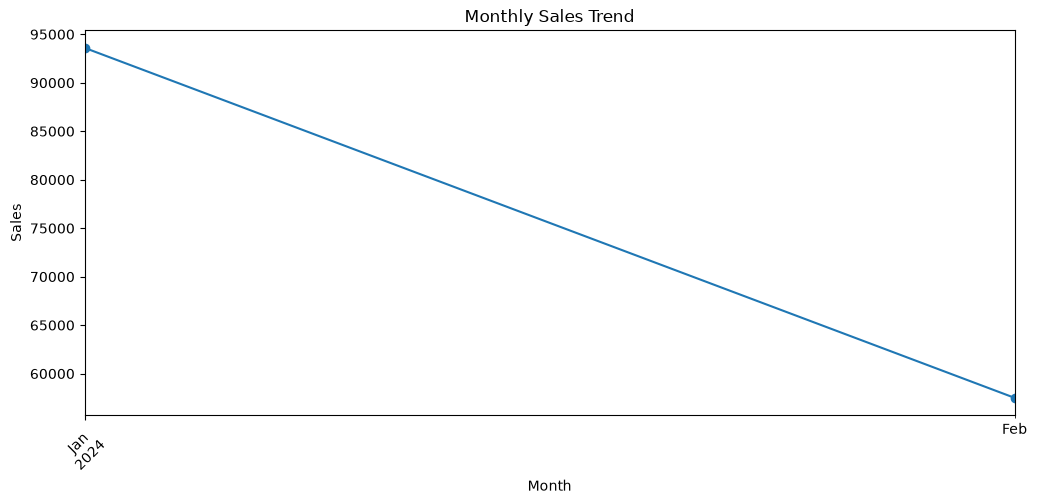

In [17]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

### Observation

The monthly sales chart shows how sales change over time.
The highest and lowest sales months can be identified from the trend.
This helps the business understand seasonal changes in customer demand.

In [18]:
quarterly_sales = df.groupby("Quarter")["Sales"].sum()

quarterly_sales

Quarter
2024Q1    151100
Freq: Q-DEC, Name: Sales, dtype: int64

C:\Users\MC USER\AppData\Roaming\Python\Python314\site-packages\pandas\plotting\_matplotlib\core.py:1615: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


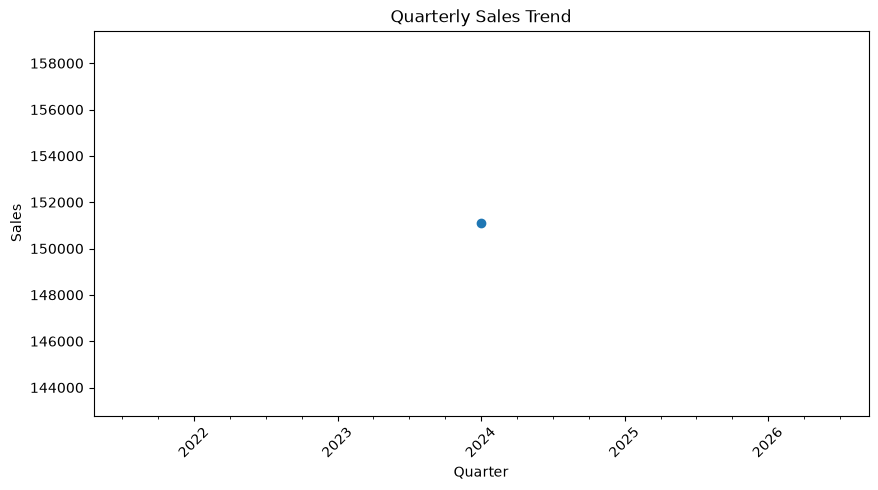

In [19]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(kind="line", marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

### Observation

The quarterly sales trend provides a broader view of business performance.
It helps identify quarters with stronger or weaker sales performance.

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=10,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=[
        "Below 18",
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56+"
    ]
)

df["Age_Group"].value_counts()

Age_Group
18-25       2
26-35       2
36-45       1
Below 18    0
46-55       0
56+         0
Name: count, dtype: int64

In [21]:
gender_count = df["Gender"].value_counts()

print(gender_count)

Gender
Male      3
Female    2
Name: count, dtype: int64


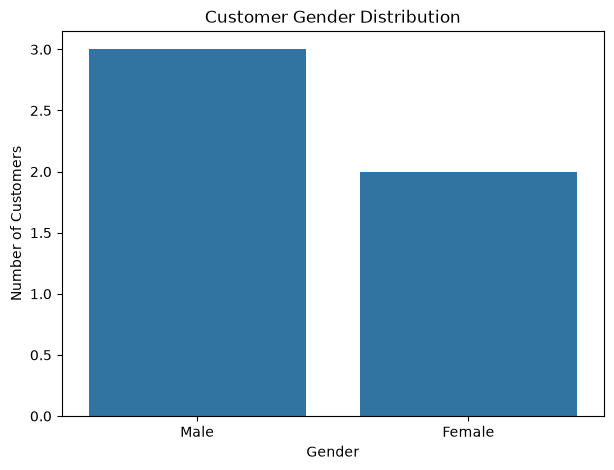

In [22]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [23]:
top_products = df["Product"].value_counts().head(10)

print(top_products)

Product
Laptop    2
Mobile    1
Shirt     1
Shoes     1
Name: count, dtype: int64


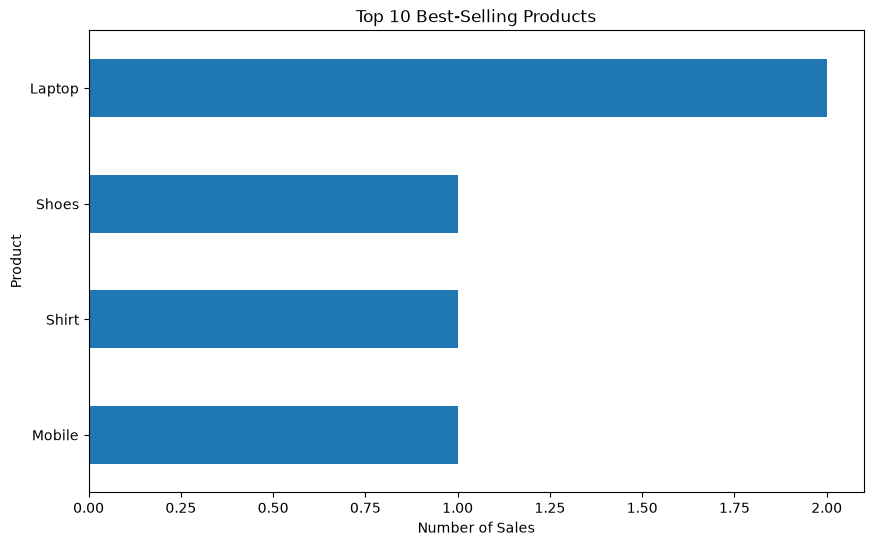

In [24]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Number of Sales")
plt.ylabel("Product")

plt.show()

In [25]:
category_revenue = df.groupby(
    "Product_Category"
)["Sales"].sum().sort_values(ascending=False)

print(category_revenue)

Product_Category
Electronics    145000
Clothing         3600
Footwear         2500
Name: Sales, dtype: int64


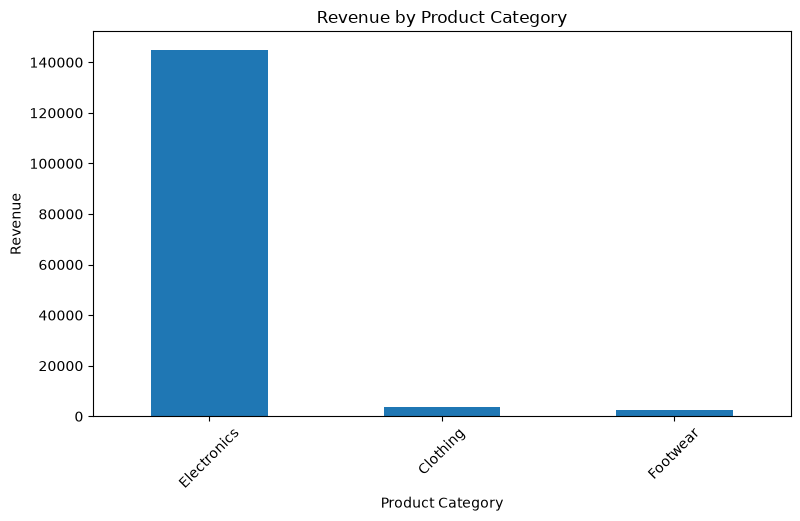

In [26]:
plt.figure(figsize=(9, 5))

category_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

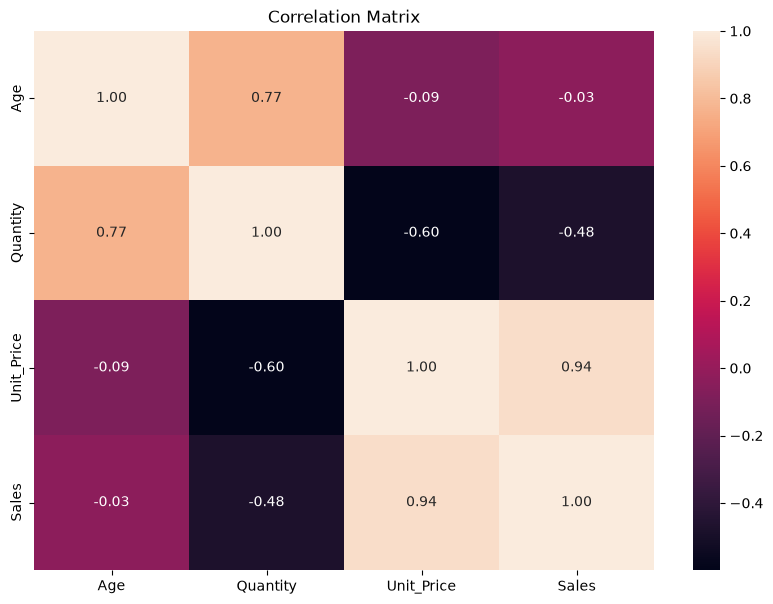

In [27]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

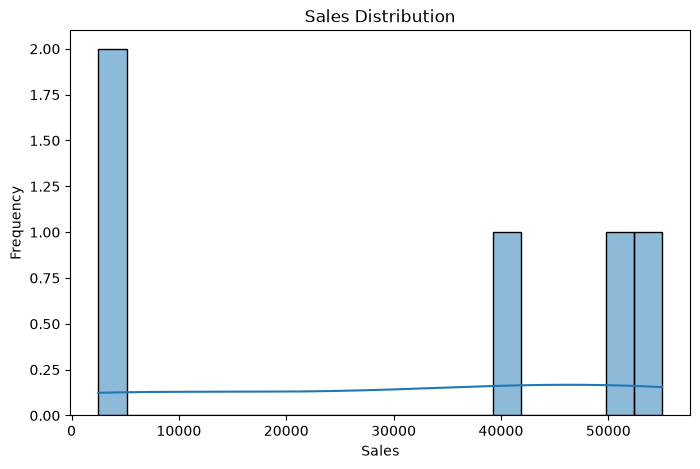

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Sales",
    bins=20,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [29]:
print("Total Sales:", df["Sales"].sum())

print("Average Sales:", df["Sales"].mean())

print("Highest Sale:", df["Sales"].max())

print("Lowest Sale:", df["Sales"].min())

print("\nBest Selling Product:")
print(df["Product"].value_counts().idxmax())

print("\nBest Revenue Category:")
print(category_revenue.idxmax())

Total Sales: 151100
Average Sales: 30220.0
Highest Sale: 55000
Lowest Sale: 2500

Best Selling Product:
Laptop

Best Revenue Category:
Electronics
